# Setup and Data Preprocessing

### What this cell does:
1. **Import Libraries:** pandas/numpy for data, matplotlib/seaborn for plots, scikit-learn/xgboost for modeling.
2. **Load Data:** reads `diabetes_dataset.csv`.
3. **Train/Test Split FIRST:** the split happens **before** any imputation or scaling is fit, so no
   statistic derived from the test set ever leaks into preprocessing.
4. **Data Imputation:** in this dataset, a `0` in Glucose, BloodPressure, SkinThickness, Insulin, or BMI is
   physiologically impossible, so it is treated as missing. A `SimpleImputer(strategy='median')` is *fit
   on the training split only* and then applied to both splits (`imputer.pkl` is exported for reuse).
5. **Feature Scaling:** `StandardScaler` is likewise fit on the training split only (`scaler.pkl` exported)
   so distance-based models (KNN, SVM) see all features on a comparable scale.
6. **Shared evaluation helper:** `evaluate_model(...)` computes Accuracy, Precision, Recall, F1, and a full
   `classification_report` for every model (previously only Accuracy + a confusion matrix were reported),
   and keeps a running `model_metrics` table used by the Experiment 1 comparison and by automatic best-model
   selection later in the notebook.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from matplotlib.colors import LinearSegmentedColormap

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
)

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

# 1. Load Data
df = pd.read_csv("diabetes_dataset.csv")

# 2. Split BEFORE any imputation/scaling, so no test-set statistic
#    ever leaks into preprocessing decisions.
X = df.drop('Outcome', axis=1)
y = df['Outcome']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
X_train, X_test = X_train.copy(), X_test.copy()

# 3. Treat physiologically-impossible zeros as missing, then impute
#    using statistics learned from the TRAINING split only.
cols_to_impute = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
X_train[cols_to_impute] = X_train[cols_to_impute].replace(0, np.nan)
X_test[cols_to_impute] = X_test[cols_to_impute].replace(0, np.nan)

imputer = SimpleImputer(strategy='median')
X_train[cols_to_impute] = imputer.fit_transform(X_train[cols_to_impute])
X_test[cols_to_impute] = imputer.transform(X_test[cols_to_impute])
joblib.dump(imputer, 'imputer.pkl')

# 4. Feature Scaling (fit on train only)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
joblib.dump(scaler, 'scaler.pkl')

BRAND_CMAP = LinearSegmentedColormap.from_list('brand_seq', ['#eef2ff', '#6366f1'])

# 5. Shared bookkeeping + rich-metrics helper for every model trained below
model_metrics = []
model_filenames = {}
model_needs_scaling = {}


def evaluate_model(name, model, X_te, y_te, filename, needs_scaling):
    """Score a fitted model with Accuracy/Precision/Recall/F1, log it for the
    Experiment 1 comparison table, save it to disk, and plot its confusion matrix."""
    y_pred = model.predict(X_te)
    acc = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, zero_division=0)
    rec = recall_score(y_te, y_pred, zero_division=0)
    f1 = f1_score(y_te, y_pred, zero_division=0)

    model_metrics.append({'Model': name, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1})
    model_filenames[name] = filename
    model_needs_scaling[name] = needs_scaling
    joblib.dump(model, filename)

    print(f"Accuracy: {acc*100:.2f}% | Precision: {prec:.3f} | Recall: {rec:.3f} | F1: {f1:.3f}")
    print(classification_report(y_te, y_pred, target_names=['Non-Diabetic', 'Diabetic']))

    cm = confusion_matrix(y_te, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap=BRAND_CMAP, cbar=False,
                xticklabels=['Non-Diabetic', 'Diabetic'], yticklabels=['Non-Diabetic', 'Diabetic'])
    plt.title(f'{name} Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.tight_layout()
    plt.show()
    return y_pred

# Model 1: Logistic Regression

**Definition:** Logistic regression models the probability of a discrete outcome given an input variable. It uses a sigmoid function to classify data into a binary output (0 = non-diabetic, 1 = diabetic).

**Hyperparameter Tuned:** `C` (inverse regularization strength) via 5-fold `GridSearchCV` over `[0.01, 0.1, 1, 10, 100]`.

### What this code does:
Fits the grid search on the scaled training data, selects the best `C`, then calls the shared
`evaluate_model(...)` helper to report Accuracy/Precision/Recall/F1, print a full classification
report, plot the confusion matrix, and save the tuned model to `logistic_regression.pkl`.


Best Hyperparameters: {'C': 1}
Accuracy: 70.78% | Precision: 0.600 | Recall: 0.500 | F1: 0.545
              precision    recall  f1-score   support

Non-Diabetic       0.75      0.82      0.78       100
    Diabetic       0.60      0.50      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154



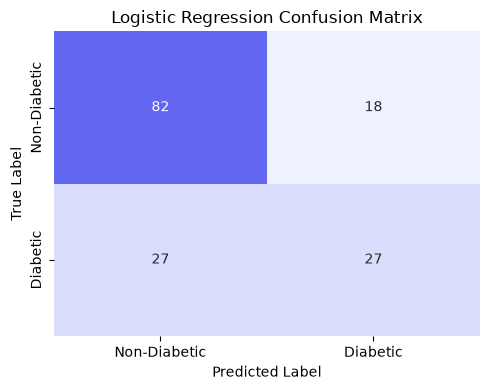

In [2]:
param_grid_lr = {'C': [0.01, 0.1, 1, 10, 100]}
grid_lr = GridSearchCV(LogisticRegression(random_state=42, max_iter=1000), param_grid_lr, cv=5, scoring='accuracy')
grid_lr.fit(X_train_scaled, y_train)
best_lr = grid_lr.best_estimator_
print(f"Best Hyperparameters: {grid_lr.best_params_}")

y_pred_lr = evaluate_model('Logistic Regression', best_lr, X_test_scaled, y_test, 'logistic_regression.pkl', needs_scaling=True)

# Model 2: Support Vector Machine (Linear Kernel)

**Definition:** Finds the optimal straight hyperplane that maximizes the margin between the two classes.

**Hyperparameter Tuned:** `C` (misclassification penalty) via 5-fold `GridSearchCV` over `[0.01, 0.1, 1, 10]`.

### What this code does:
Same protocol as Model 1: grid search on scaled training data, then `evaluate_model(...)` for the
full metric set, confusion matrix, and export to `svm_linear.pkl`.


C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in versi

C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in versi

C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in versi

Best Hyperparameters: {'C': 0.1}
Accuracy: 70.78% | Precision: 0.605 | Recall: 0.481 | F1: 0.536
              precision    recall  f1-score   support

Non-Diabetic       0.75      0.83      0.79       100
    Diabetic       0.60      0.48      0.54        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.66       154
weighted avg       0.70      0.71      0.70       154



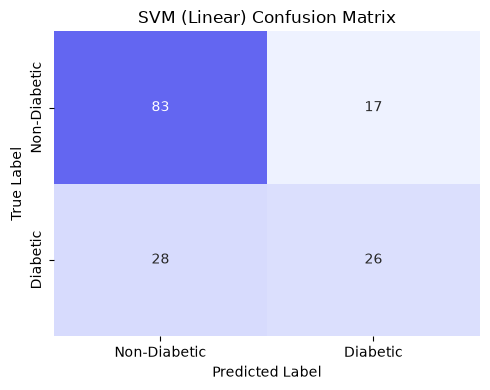

In [3]:
param_grid_svml = {'C': [0.01, 0.1, 1, 10]}
grid_svml = GridSearchCV(SVC(kernel='linear', random_state=42, probability=True), param_grid_svml, cv=5, scoring='accuracy')
grid_svml.fit(X_train_scaled, y_train)
best_svml = grid_svml.best_estimator_
print(f"Best Hyperparameters: {grid_svml.best_params_}")

y_pred_svml = evaluate_model('SVM (Linear)', best_svml, X_test_scaled, y_test, 'svm_linear.pkl', needs_scaling=True)

# Model 3: Support Vector Machine (RBF Kernel)

**Definition:** Uses a Radial Basis Function kernel to project data into a higher-dimensional space,
allowing complex, non-linear decision boundaries.

**Hyperparameters Tuned:** `C` and `gamma`, via 5-fold `GridSearchCV`.

### What this code does:
Grid-searches `C` x `gamma` on scaled training data, then reports the full metric set via
`evaluate_model(...)` and exports `svm_rbf.pkl`.


C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in versi

C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in versi

C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in versi

C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in versi

C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in versi

C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in versi

C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in versi

C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in versi

Best Hyperparameters: {'C': 10, 'gamma': 0.01}
Accuracy: 69.48% | Precision: 0.581 | Recall: 0.463 | F1: 0.515
              precision    recall  f1-score   support

Non-Diabetic       0.74      0.82      0.78       100
    Diabetic       0.58      0.46      0.52        54

    accuracy                           0.69       154
   macro avg       0.66      0.64      0.65       154
weighted avg       0.68      0.69      0.69       154



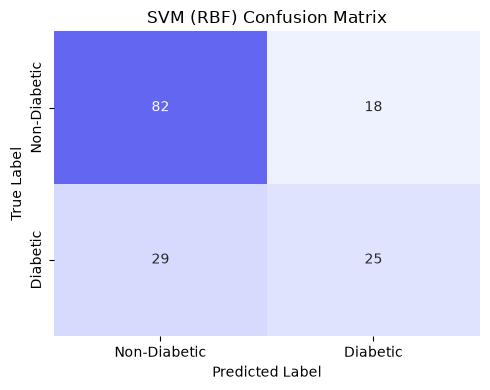

In [4]:
param_grid_svmr = {'C': [0.1, 1, 10], 'gamma': ['scale', 'auto', 0.01, 0.1]}
grid_svmr = GridSearchCV(SVC(kernel='rbf', random_state=42, probability=True), param_grid_svmr, cv=5, scoring='accuracy')
grid_svmr.fit(X_train_scaled, y_train)
best_svmr = grid_svmr.best_estimator_
print(f"Best Hyperparameters: {grid_svmr.best_params_}")

y_pred_svmr = evaluate_model('SVM (RBF)', best_svmr, X_test_scaled, y_test, 'svm_rbf.pkl', needs_scaling=True)

# Model 4: K-Nearest Neighbors (KNN)

**Definition:** A lazy learner — to classify a new patient it looks at the `k` most similar training
patients and takes a (possibly distance-weighted) majority vote.

**Hyperparameters Tuned:** `n_neighbors` in `[3, 5, 7, 9]`, `weights` in `['uniform', 'distance']`.

### What this code does:
Because KNN relies purely on distance, it is grid-searched on the **scaled** training data. The full
`grid_knn.cv_results_` (every k x weights combination) is reused later in **Experiment 2** to show how
accuracy changes with `k`, rather than only reporting the single best value.


Best Hyperparameters: {'n_neighbors': 9, 'weights': 'uniform'}
Accuracy: 74.03% | Precision: 0.635 | Recall: 0.611 | F1: 0.623
              precision    recall  f1-score   support

Non-Diabetic       0.79      0.81      0.80       100
    Diabetic       0.63      0.61      0.62        54

    accuracy                           0.74       154
   macro avg       0.71      0.71      0.71       154
weighted avg       0.74      0.74      0.74       154



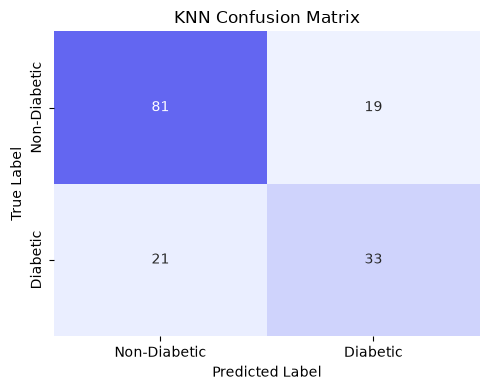

In [5]:
param_grid_knn = {'n_neighbors': [3, 5, 7, 9], 'weights': ['uniform', 'distance']}
grid_knn = GridSearchCV(KNeighborsClassifier(), param_grid_knn, cv=5, scoring='accuracy')
grid_knn.fit(X_train_scaled, y_train)
best_knn = grid_knn.best_estimator_
print(f"Best Hyperparameters: {grid_knn.best_params_}")

y_pred_knn = evaluate_model('KNN', best_knn, X_test_scaled, y_test, 'knn.pkl', needs_scaling=True)

# Model 5: Random Forest

**Definition:** An ensemble of decision trees trained on random subsets of data/features; predictions
are combined by majority vote.

**Hyperparameters Tuned:** `n_estimators`, `max_depth`, via 5-fold `GridSearchCV`.

### What this code does:
Tree-based models do not require feature scaling, so this cell grid-searches directly on the
**unscaled** `X_train`, then reports the full metric set via `evaluate_model(...)` and exports
`random_forest.pkl`.


Best Hyperparameters: {'max_depth': None, 'n_estimators': 100}
Accuracy: 76.62% | Precision: 0.696 | Recall: 0.593 | F1: 0.640
              precision    recall  f1-score   support

Non-Diabetic       0.80      0.86      0.83       100
    Diabetic       0.70      0.59      0.64        54

    accuracy                           0.77       154
   macro avg       0.75      0.73      0.73       154
weighted avg       0.76      0.77      0.76       154



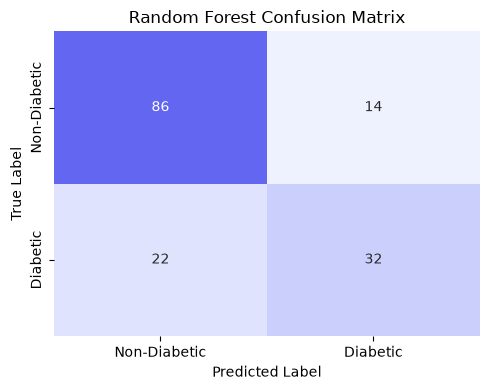

In [6]:
param_grid_rf = {'n_estimators': [50, 100, 200], 'max_depth': [None, 5, 10]}
grid_rf = GridSearchCV(RandomForestClassifier(random_state=42), param_grid_rf, cv=5, scoring='accuracy')
grid_rf.fit(X_train, y_train)
best_rf = grid_rf.best_estimator_
print(f"Best Hyperparameters: {grid_rf.best_params_}")

y_pred_rf = evaluate_model('Random Forest', best_rf, X_test, y_test, 'random_forest.pkl', needs_scaling=False)

# Model 6: XGBoost (Extreme Gradient Boosting)

**Definition:** Trees are added sequentially, each one correcting the residual errors of the ensemble
built so far.

**Hyperparameters Tuned:** `n_estimators`, `learning_rate`, `max_depth`, via 5-fold `GridSearchCV`.

### What this code does:
Grid-searches on the unscaled training data, reports the full metric set via `evaluate_model(...)`,
and exports `xgboost.pkl`.


Best Hyperparameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 50}
Accuracy: 74.68% | Precision: 0.653 | Recall: 0.593 | F1: 0.621
              precision    recall  f1-score   support

Non-Diabetic       0.79      0.83      0.81       100
    Diabetic       0.65      0.59      0.62        54

    accuracy                           0.75       154
   macro avg       0.72      0.71      0.72       154
weighted avg       0.74      0.75      0.74       154



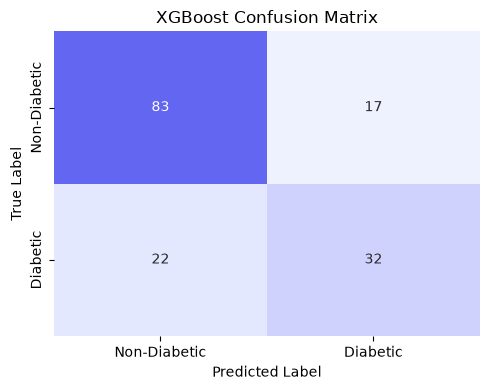

In [7]:
param_grid_xgb = {'n_estimators': [50, 100, 200], 'learning_rate': [0.01, 0.1, 0.2], 'max_depth': [3, 5]}
grid_xgb = GridSearchCV(xgb.XGBClassifier(eval_metric='logloss', random_state=42), param_grid_xgb, cv=5, scoring='accuracy')
grid_xgb.fit(X_train, y_train)
best_xgb = grid_xgb.best_estimator_
print(f"Best Hyperparameters: {grid_xgb.best_params_}")

y_pred_xgb = evaluate_model('XGBoost', best_xgb, X_test, y_test, 'xgboost.pkl', needs_scaling=False)

# Final Model Comparison

### What this code does:
Builds a table from `model_metrics` (Accuracy, Precision, Recall, F1 for every tuned model), sorts it
by **F1** (a better summary than raw Accuracy on an imbalanced medical dataset), displays it, and plots
an Accuracy bar chart with the exact percentage labelled on each bar.


=== Final Model Comparison (sorted by F1) ===


,Model,Accuracy,Precision,Recall,F1
0,Random Forest,76.62%,0.696,0.593,0.640
1,KNN,74.03%,0.635,0.611,0.623
2,XGBoost,74.68%,0.653,0.593,0.621
3,Logistic Regression,70.78%,0.600,0.500,0.545
4,SVM (Linear),70.78%,0.605,0.481,0.536
5,SVM (RBF),69.48%,0.581,0.463,0.515


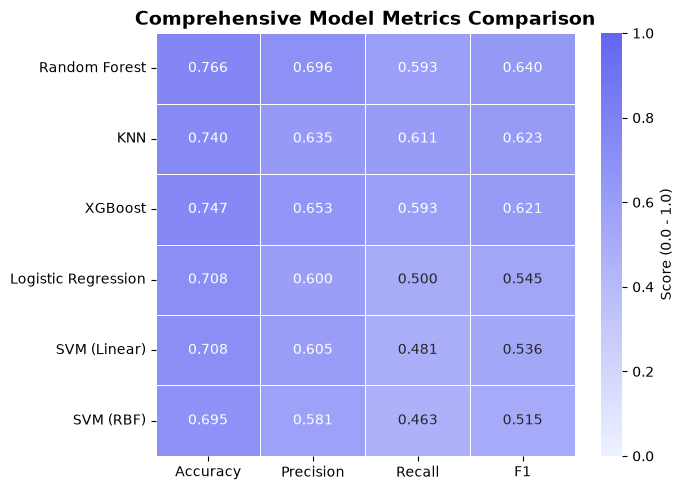

In [8]:
results_df = pd.DataFrame(model_metrics)
results_df_display = results_df.copy()
results_df_display['Accuracy'] = results_df_display['Accuracy'] * 100
results_df_display = results_df_display.sort_values(by='F1', ascending=False).reset_index(drop=True)

print("=== Final Model Comparison (sorted by F1) ===")
display(results_df_display.style.format({
    'Accuracy': '{:.2f}%', 'Precision': '{:.3f}', 'Recall': '{:.3f}', 'F1': '{:.3f}'
}))

# Annotated heatmap comparing all 4 metrics across all models
# (a 6x4 heatmap reads far more clearly than a 24-bar grouped bar chart)
import matplotlib.pyplot as plt
comparison_df = results_df.copy().set_index('Model')
comparison_df = comparison_df.sort_values(by='F1', ascending=False)

plt.figure(figsize=(7, 5))
sns.heatmap(comparison_df, annot=True, fmt='.3f', cmap=BRAND_CMAP, vmin=0, vmax=1,
            linewidths=0.5, linecolor='white', cbar_kws={'label': 'Score (0.0 - 1.0)'})
plt.title('Comprehensive Model Metrics Comparison', fontsize=14, fontweight='bold')
plt.xlabel('')
plt.ylabel('')
plt.tight_layout()
plt.show()